### Install Libraries

In [1]:
pip install pandas numpy nltk scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df = pd.read_csv("data/Symptom2Disease.csv")
df.head()

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1200 non-null   int64 
 1   label       1200 non-null   object
 2   text        1200 non-null   object
dtypes: int64(1), object(2)
memory usage: 28.3+ KB


In [4]:
df.describe()

,Unnamed: 0
count,1200.000000
mean,149.500000
std,86.638166
min,0.000000
25%,74.750000
50%,149.500000
75%,224.250000
max,299.000000


### NLP Pipeline :

In [5]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [7]:
df.columns

Index(['label', 'text'], dtype='object')

In [10]:
#clean text

import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

df["cleaned_text"] = df["text"].apply(clean_text)

In [11]:
df.head(10)

,label,text,cleaned_text
0,Psoriasis,I have been experiencing a skin rash on my arm...,i have been experiencing a skin rash on my arm...
1,Psoriasis,"My skin has been peeling, especially on my kne...",my skin has been peeling especially on my knee...
2,Psoriasis,I have been experiencing joint pain in my fing...,i have been experiencing joint pain in my fing...
3,Psoriasis,"There is a silver like dusting on my skin, esp...",there is a silver like dusting on my skin espe...
4,Psoriasis,"My nails have small dents or pits in them, and...",my nails have small dents or pits in them and ...
5,Psoriasis,The skin on my palms and soles is thickened an...,the skin on my palms and soles is thickened an...
6,Psoriasis,"The skin around my mouth, nose, and eyes is re...",the skin around my mouth nose and eyes is red ...
7,Psoriasis,My skin is very sensitive and reacts easily to...,my skin is very sensitive and reacts easily to...
8,Psoriasis,I have noticed a sudden peeling of skin at dif...,i have noticed a sudden peeling of skin at dif...
9,Psoriasis,The skin on my genitals is red and inflamed. I...,the skin on my genitals is red and inflamed it...


In [13]:
#Tokenization

import nltk
nltk.download('punkt_tab')

import nltk
nltk.download('punkt')

from nltk.tokenize import word_tokenize

df["tokens"] = df["cleaned_text"].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\engsa\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\engsa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [14]:
#STEP 4: Remove Stopwords

from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(
    lambda words: [w for w in words if w not in stop_words]
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\engsa\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [16]:
#STEP 5: Lemmatization

from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df["tokens"] = df["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(w) for w in words]
)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\engsa\AppData\Roaming\nltk_data...


In [19]:
df["final_text"] = df["tokens"].apply(lambda x: " ".join(x))

In [25]:
#Now lets take a look at all of our classes (diseases)

diseases = df.label.unique() 

print(f"Number of classes (diseases): {len(diseases)} \nClasses (diseases):\n{diseases}")

Number of classes (diseases): 24 
Classes (diseases):
['Psoriasis' 'Varicose Veins' 'Typhoid' 'Chicken pox' 'Impetigo' 'Dengue'
 'Fungal infection' 'Common Cold' 'Pneumonia' 'Dimorphic Hemorrhoids'
 'Arthritis' 'Acne' 'Bronchial Asthma' 'Hypertension' 'Migraine'
 'Cervical spondylosis' 'Jaundice' 'Malaria' 'urinary tract infection'
 'allergy' 'gastroesophageal reflux disease' 'drug reaction'
 'peptic ulcer disease' 'diabetes']


In [26]:
symptoms_per_disease = df.label.value_counts()


In [27]:
from plotly import graph_objs as go

def go_bar(x_col, y_col, title):
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=x_col,
        y=y_col
    ))
    
    fig.update_layout(
        title=f'<span  style="font-size:32px">{title}</span>'
    )
    fig.show()

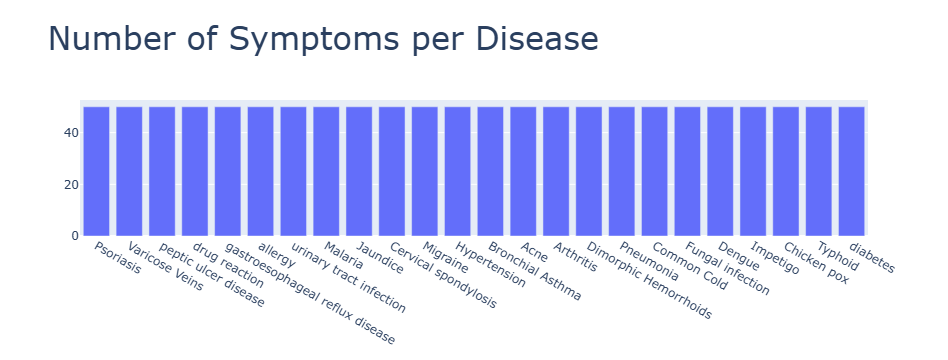

In [28]:
x_col = symptoms_per_disease.index
y_col = symptoms_per_disease.values

title = 'Number of Symptoms per Disease'
go_bar(x_col, y_col, title)

### Split Dataset Into Train and Test

In [29]:
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df.label

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
print(f"Number of classes (diseases): {y_train.nunique() }")

Number of classes (diseases): 24


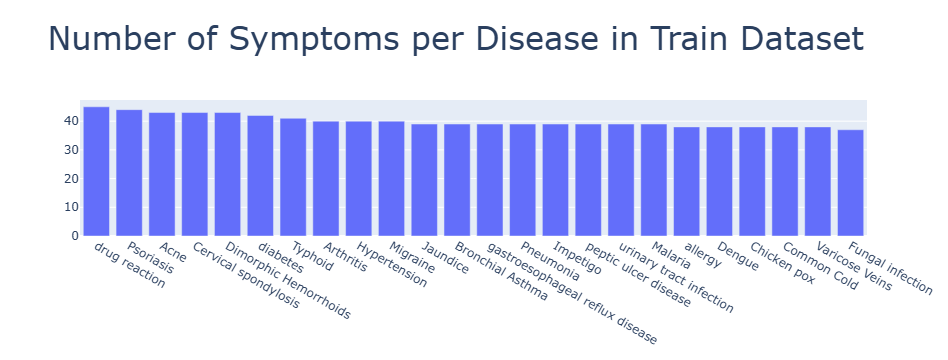

In [32]:
symptoms_per_disease_train = y_train.value_counts()

x_col = symptoms_per_disease_train.index
y_col = symptoms_per_disease_train.values

title = 'Number of Symptoms per Disease in Train Dataset'
go_bar(x_col, y_col, title)

Encoding

In [33]:
from sklearn.preprocessing import LabelEncoder

# onvert name of disease to num
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [34]:
# to see which disease each number represents
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("Mapping Dictionary:")
print(mapping)

# Look at the first 5 rows after the conversion and compare them to the originals.
check_df = pd.DataFrame({'Original': y_test[:5].values, 'Encoded': y_test_encoded[:5]})
print("\nCheck first 5 rows:")
print(check_df)

Mapping Dictionary:
{'Acne': 0, 'Arthritis': 1, 'Bronchial Asthma': 2, 'Cervical spondylosis': 3, 'Chicken pox': 4, 'Common Cold': 5, 'Dengue': 6, 'Dimorphic Hemorrhoids': 7, 'Fungal infection': 8, 'Hypertension': 9, 'Impetigo': 10, 'Jaundice': 11, 'Malaria': 12, 'Migraine': 13, 'Pneumonia': 14, 'Psoriasis': 15, 'Typhoid': 16, 'Varicose Veins': 17, 'allergy': 18, 'diabetes': 19, 'drug reaction': 20, 'gastroesophageal reflux disease': 21, 'peptic ulcer disease': 22, 'urinary tract infection': 23}

Check first 5 rows:
         Original  Encoded
0        diabetes       19
1         Malaria       12
2         Typhoid       16
3       Pneumonia       14
4  Varicose Veins       17


### save cleaned data

In [36]:
train.to_csv("cleaned_data/train.csv", index=False)
val.to_csv("cleaned_data/val.csv", index=False)